# FlexTok AR: Quickstart

Generate images with **FlexTok AR**, a series of autoregressive image generation models built on [FlexTok](https://github.com/apple/ml-flextok) 1D ordered tokens. The AR model predicts a sequence of up to 256 discrete visual tokens (vocab: 64k) conditioned on a text prompt (T2I) or ImageNet class label (C2I), which are then decoded to pixels via a flow-matching diffusion decoder. Because tokens are generated left-to-right, any prefix can be decoded — revealing the image's coarse-to-fine structure.

This notebook covers:
- **Section 1** — Text-to-Image (T2I) generation with progressive decoding
- **Section 2** — Class-to-Image (C2I) generation on ImageNet classes

In [1]:
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger().setLevel(logging.WARNING)

import torch
import matplotlib.pyplot as plt
from flextok_ar.utils.helpers import load_model, tensor_to_pil
from soto.utils import set_seed

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

FIXED_SEED = 0
set_seed(FIXED_SEED)
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print(f"Fixed seed set to: {FIXED_SEED}")

Could not import `moe`. MoE training is not possible: No module named 'megablocks'


Python version is above 3.10, patching the collections module.
Using device: cuda:0
Fixed seed set to: 0


## 1. Text-to-Image (T2I) Generation

In [2]:
model, tokenizer, cfg = load_model(
    model_id="EPFL-VILAB/FlexAR-3B-T2I",
    device=device,
)
print("Model loaded!")
print(f"Generation config:\n  {dict(cfg.generation)}")


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 91.50it/s]


Model loaded!
Generation config:
  {'model_type': 'ar_text_to_image_model', 'sample': True, 'temperature': 1.0, 'top_k': 0, 'top_p': 0.0, 'cfg_factor': 3.0, 'num_keep_tokens': 256, 'num_samples': 1, 'timesteps': 25, 'tokenizer_cfg_factor': 7.5, 'tokenizer_perform_norm_guidance': True}


### 1.1 Load Model

`load_model` downloads the checkpoint from HuggingFace (or uses cache) and returns:

| Object | Type | Description |
|---|---|---|
| `model` | `ImageGenerationWrapper` | AR transformer + decode pipeline |
| `tokenizer` | `ImageResamplerTokenizer` | FlexTok encoder/decoder (tokens ↔ pixels) |
| `cfg` | OmegaConf | Model config with generation hyperparameters |

### 1.2 Visualizing the Generation Process

FlexTok AR generates tokens one at a time, each adding progressively more detail. We generate all 256 tokens, then decode at increasing prefix lengths (1 → 4 → 8 → … → 256) to visualize this structure.

In [3]:
def progressive_decode(model, tokenizer, cfg, prompt=None, class_label=None,
                       token_counts=None, seed=None, device="cuda", verbose=False):
    """Generate 256 tokens in one AR pass, then decode at increasing prefix lengths."""
    if token_counts is None:
        token_counts = [1, 4, 8, 16, 32, 64, 128, 256]
    if seed is not None:
        torch.manual_seed(seed)

    gen_cfg = cfg.generation
    data_dict = ({"text": [prompt]} if prompt is not None else
                 {"target": torch.tensor([class_label], dtype=torch.long, device=device)})

    # Step 1: AR forward — generate all 256 token IDs in a single pass
    with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float32):
        token_ids = model.generate_ids(
            data_dict,
            sample=gen_cfg.get("sample", True),
            temperature=gen_cfg.get("temperature", 1.0),
            cfg_factor=gen_cfg.get("cfg_factor", 3.0),
            num_keep_tokens=gen_cfg.get("num_keep_tokens", 256),
        )

    # Step 2: decode each prefix — reveals the coarse-to-fine structure
    partial_images = []
    for n_tok in token_counts:
        with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
            result = tokenizer.decode(
                data_dict={"image_token_ids": token_ids[:, :n_tok]},
                timesteps=gen_cfg.get("timesteps", 25),
                guidance_scale=gen_cfg.get("tokenizer_cfg_factor", 7.5),
                perform_norm_guidance=gen_cfg.get("tokenizer_perform_norm_guidance", True),
                verbose=verbose,
            )
        partial_images.append(tensor_to_pil(result["decoded_images"][0]))

    return token_ids, partial_images

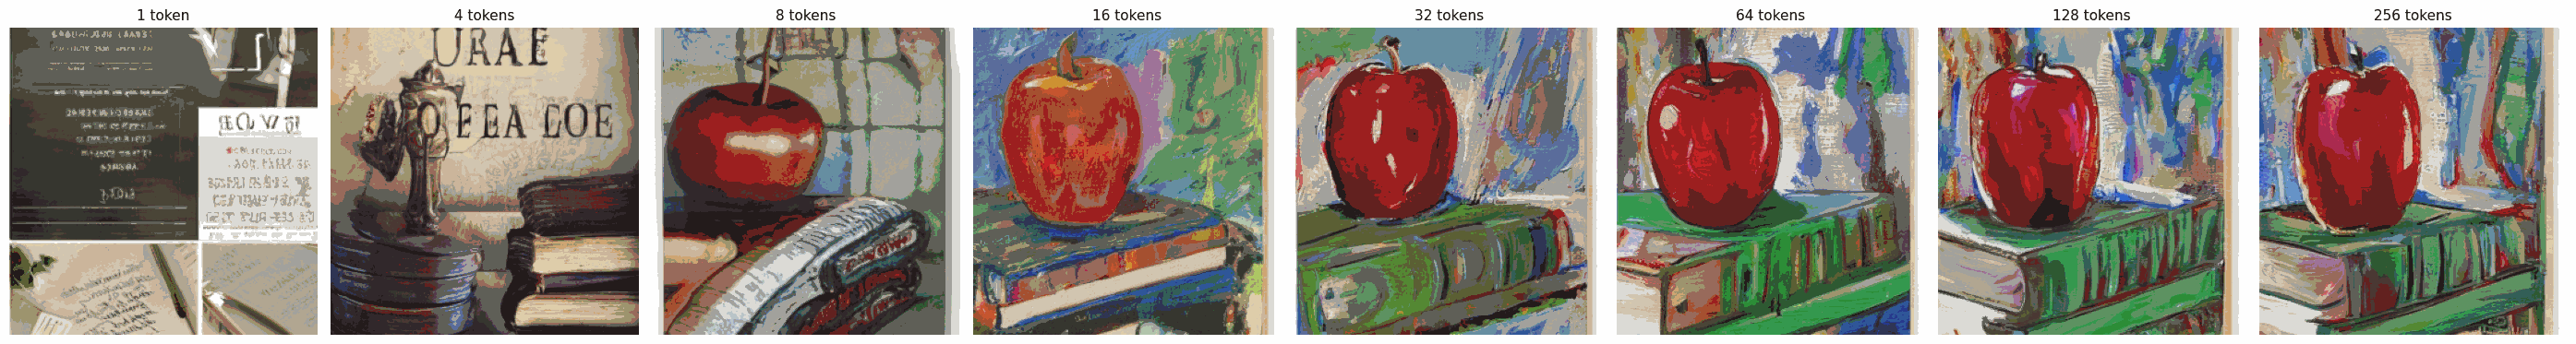

In [4]:
set_seed(FIXED_SEED)
prompt = "A painting of a red apple resting on a green book against a colorful abstract background."

token_ids, partial_images = progressive_decode(
    model, tokenizer, cfg, prompt=prompt, seed=FIXED_SEED, device=device, verbose=False
)
token_counts = [1, 4, 8, 16, 32, 64, 128, 256]

fig, axes = plt.subplots(1, len(token_counts), figsize=(3.5 * len(token_counts), 4))
for ax, img, n in zip(axes, partial_images, token_counts):
    ax.imshow(img)
    ax.set_title(f"{n} token{'s' if n > 1 else ''}", fontsize=11)
    ax.axis("off")
plt.tight_layout()
plt.show()




### 1.3 Direct Generation

`model.generate` runs the full AR + decode pipeline in one call.

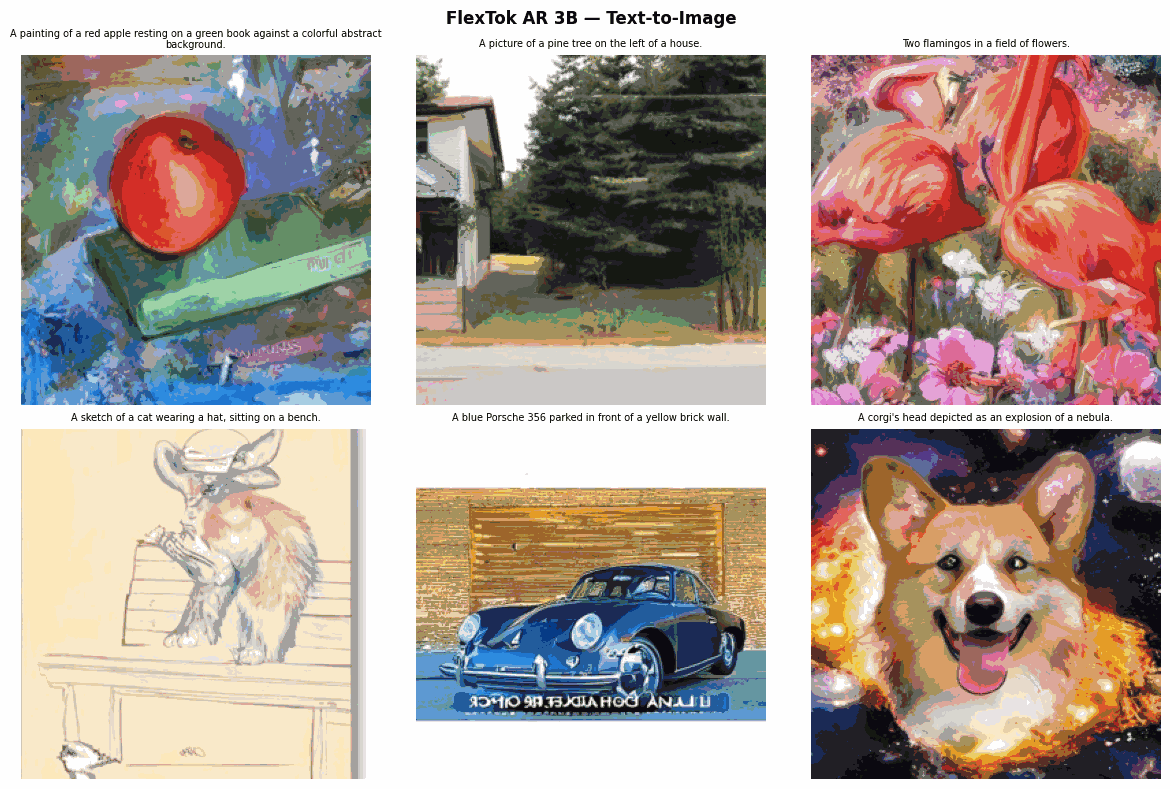

In [5]:
PROMPTS = [
    "A painting of a red apple resting on a green book against a colorful abstract background.",
    "A picture of a pine tree on the left of a house.",
    "Two flamingos in a field of flowers.",
    "A sketch of a cat wearing a hat, sitting on a bench.",
    "A blue Porsche 356 parked in front of a yellow brick wall.",
    "A corgi's head depicted as an explosion of a nebula.",
]

t2i_images = []
for prompt in PROMPTS:
    data_dict = {"text": [prompt]}
    imgs = model.generate(data_dict, **dict(cfg.generation))
    t2i_images.append(tensor_to_pil(imgs[0]))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, img, prompt in zip(axes.flat, t2i_images, PROMPTS):
    ax.imshow(img)
    ax.set_title(prompt, fontsize=7, wrap=True)
    ax.axis("off")
plt.suptitle("FlexTok AR 3B — Text-to-Image", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Class-to-Image (C2I) Generation

### 2.1 Load Model

Load a FlexTok AR model trained on ImageNet for class-conditional generation.

In [6]:
# Load the model
model, tokenizer, cfg = load_model(
    model_id="EPFL-VILAB/FlexAR-1B-C2I",
    device=device,
)
print("Model loaded!")
print(f"Generation config:\n  {dict(cfg.generation)}")

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 14691.08it/s]


Model loaded!
Generation config:
  {'model_type': 'ar_label_to_image_model', 'sample': True, 'temperature': 1.0, 'top_k': 0, 'top_p': 0.0, 'cfg_factor': 1.5, 'num_keep_tokens': 256, 'num_samples': 1, 'timesteps': 25, 'tokenizer_cfg_factor': 7.5, 'tokenizer_perform_norm_guidance': True}


### 2.2 Visualizing the Generation Process (C2I)

Same progressive decoding visualization for class-conditional generation.

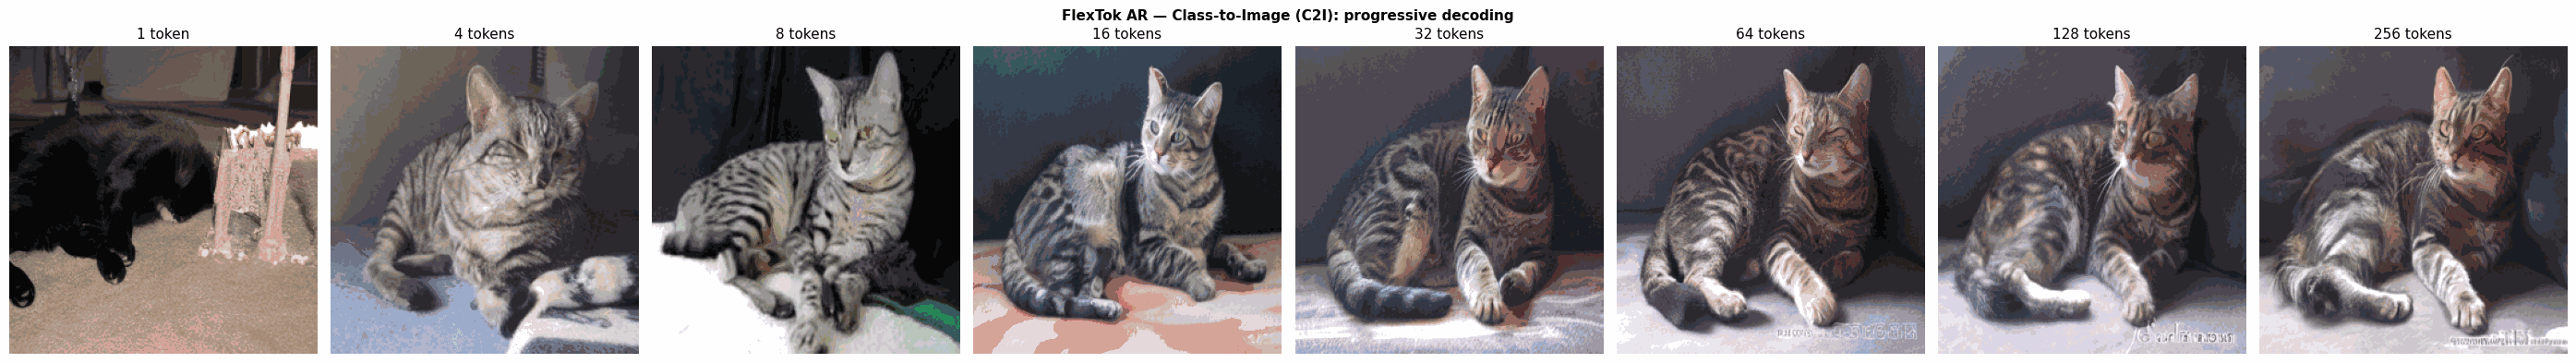

In [7]:
# Progressive decoding: tokens building an image from class label 281 (tabby cat)
set_seed(FIXED_SEED)
CLASS_LABEL = 281  # tabby cat

_, partial_images = progressive_decode(
    model, tokenizer, cfg, class_label=CLASS_LABEL, seed=FIXED_SEED, device=device, verbose=False
)
token_counts = [1, 4, 8, 16, 32, 64, 128, 256]

fig, axes = plt.subplots(1, len(token_counts), figsize=(3.5 * len(token_counts), 4))
for ax, img, n in zip(axes, partial_images, token_counts):
    ax.imshow(img)
    ax.set_title(f"{n} token{'s' if n > 1 else ''}", fontsize=11)
    ax.axis("off")
plt.suptitle("FlexTok AR — Class-to-Image (C2I): progressive decoding", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.3 Direct Generation (gallery)

Generate final images for several ImageNet classes.

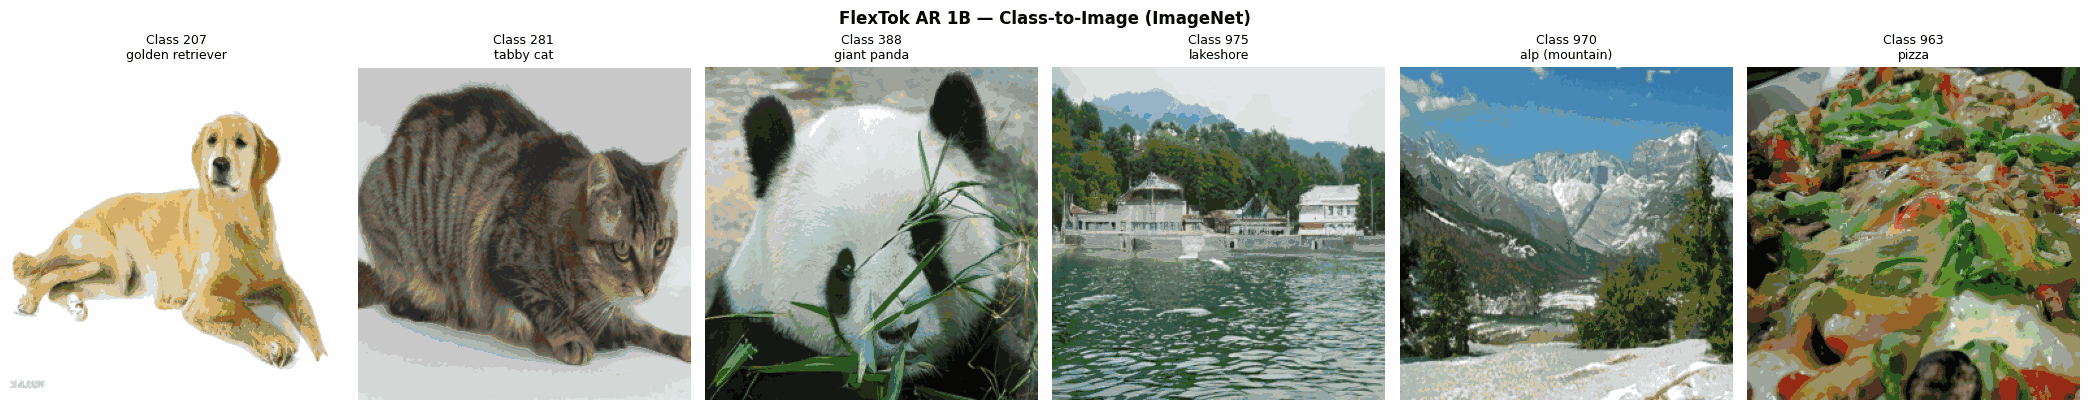

In [8]:
IMAGENET_CLASSES = {
    207: "golden retriever",
    281: "tabby cat",
    388: "giant panda",
    975: "lakeshore",
    970: "alp (mountain)",
    963: "pizza",
}

labels_to_show = [207, 281, 388, 975, 970, 963]
c2i_images = []

for label in labels_to_show:
    # Same interface as T2I — just swap the data_dict key
    data_dict = {"target": torch.tensor([label], dtype=torch.long, device=device)}
    imgs = model.generate(data_dict, **dict(cfg.generation))
    c2i_images.append(tensor_to_pil(imgs[0]))

fig, axes = plt.subplots(1, len(labels_to_show), figsize=(3.5 * len(labels_to_show), 4))
for ax, img, label in zip(axes, c2i_images, labels_to_show):
    ax.imshow(img)
    ax.set_title(f"Class {label}\n{IMAGENET_CLASSES[label]}", fontsize=9)
    ax.axis("off")
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.suptitle("FlexTok AR 1B — Class-to-Image (ImageNet)", fontsize=12, fontweight="bold", y=1.02)
plt.show()

## Other Model Variants

All variants use the same `load_model` + `model.generate` interface — just swap `model_id`.

| Model | Params | Task | `model_id` | Token Type |
|---|---|---|---|---|
| FlexAR-113M | 113M | T2I | `EPFL-VILAB/FlexAR-113M-T2I` | 1D ordered |
| FlexAR-382M | 382M | T2I | `EPFL-VILAB/FlexAR-382M-T2I` | 1D ordered |
| FlexAR-1B | 1.15B | T2I | `EPFL-VILAB/FlexAR-1B-T2I` | 1D ordered |
| **FlexAR-3B** | **3.06B** | **T2I** | **`EPFL-VILAB/FlexAR-3B-T2I`** ← used above | 1D ordered |
| GridAR-3B | 3.06B | T2I | `EPFL-VILAB/GridAR-3B-T2I` | 2D grid (16×16) |
| FlexAR-1B | 1.15B | C2I | `EPFL-VILAB/FlexAR-1B-C2I` ← used above | 1D ordered |

In [9]:
# To try another model variant, replace model_id and re-run from the "Load the Model" cell.
# The generate_t2i / generate_c2i / progressive-decoding cells all work unchanged.

# model_id = "EPFL-VILAB/FlexAR-113M-T2I"  
# model_id = "EPFL-VILAB/FlexAR-382M-T2I"
# model_id = "EPFL-VILAB/FlexAR-1B-T2I"
# model_id = "EPFL-VILAB/FlexAR-3B-T2I"      
# model_id = "EPFL-VILAB/GridAR-3B-T2I"      # 2D spatial grid tokenization
# model_id = "EPFL-VILAB/FlexAR-1B-C2I"      # C2I (class-to-image)

# model, tokenizer, cfg = load_model(model_id=model_id, device=device)
print("Uncomment a model_id above and re-run to switch models.")

Uncomment a model_id above and re-run to switch models.


## Takeaways

- **FlexTok AR generates images as ordered 1D token sequences.** Each token adds progressively more detail, and any prefix can be decoded into a complete (though coarser) image.
- **The same `load_model` + `model.generate` interface** works across all model variants (113M–3B, T2I and C2I) — just swap the `model_id`.
- **Progressive decoding visualizes the coarse-to-fine structure**, showing how early tokens capture global semantics and later tokens refine fine details.

## Next Steps

The notebooks in `../notebooks/` show how to improve quality with **test-time search**:

- **`01_quickstart.ipynb`** — Beam search, Best-of-N, Lookahead on FlexTok AR; FlexTok vs GridTok comparison
- **`02_ar_free_search.ipynb`** — Training-free generation via pure token search (no AR model)
- **`03_verifiers.ipynb`** — CLIP, ImageReward, DreamSim, Ensemble verifiers
- **`04_other_ar_models.ipynb`** — Beam search on Janus-Pro 7B and Infinity 2B